<a href="https://colab.research.google.com/github/truongkiet545787/faster-rcnn-object-detection/blob/main/pytorch_faster_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import torch
from torchvision.datasets import VOCDetection
import pprint as pprint

In [36]:
train_data = VOCDetection(root = '/content/VOC_dataset',year='2012',image_set='train',download=False)

{'annotation': {'filename': '2008_000008.jpg',
                'folder': 'VOC2012',
                'object': [{'bndbox': {'xmax': '471',
                                       'xmin': '53',
                                       'ymax': '420',
                                       'ymin': '87'},
                            'difficult': '0',
                            'name': 'horse',
                            'occluded': '1',
                            'pose': 'Left',
                            'truncated': '0'},
                           {'bndbox': {'xmax': '289',
                                       'xmin': '158',
                                       'ymax': '167',
                                       'ymin': '44'},
                            'difficult': '0',
                            'name': 'person',
                            'occluded': '0',
                            'pose': 'Unspecified',
                            'truncated': '1'}],
                'segme

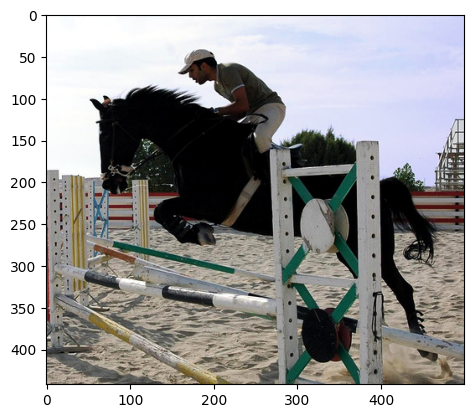

In [37]:
img,label = train_data[0]
pprint.pprint(label)
import matplotlib.pyplot as plt
plt.imshow(img)

model faster R CNN expected
+ list of tensor range 0-1
+ target expect list of dictionary, containing:
  - boxes: float tensor (n,4)
  - label: int64 tensor (n)

In [38]:
from torchvision.transforms import Compose, ToTensor,Normalize,ColorJitter, RandomAffine
transform = Compose([
    # RandomAffine(
    #     degrees = (-5,5),
    #     translate = (0.15,0.15),
    #     scale=(0.85,1.15),
    #     shear=10
    # ),
    # ColorJitter(
    #     brightness = 0.5,
    #     contrast = 0.5,
    #     saturation = 0.5,
    #     hue = 0.05
    # ),
    ToTensor(),
    # Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [39]:
# kế thừa class vocdection
class VOCdataset(VOCDetection):
  def __init__(self,root,year,image_set,download,transform):
    super().__init__(root,year,image_set,download,transform)
    self.categorical =[
    "background","aeroplane", "bicycle", "bird", "boat",
    "bottle", "bus", "car", "cat", "chair",
    "cow", "diningtable", "dog", "horse",
    "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]

  def __getitem__(self,index):
    img,label = super().__getitem__(index)
    # print(label['annotation'].keys())
    all_boxes, all_label = [],[]
    for i in label['annotation']['object']:
      xmin = int(i['bndbox']['xmin'])
      ymin = int(i['bndbox']['ymin'])
      xmax = int(i['bndbox']['xmax'])
      ymax = int(i['bndbox']['ymax'])
      all_boxes.append([xmin,ymin,xmax,ymax])
      all_label.append(self.categorical.index(i['name']))
    all_boxes = torch.FloatTensor(all_boxes)
    all_label = torch.LongTensor(all_label)
    target = {
        'boxes' : all_boxes,
        'labels' : all_label

    }
    return img, target


In [40]:
dataset = VOCdataset(root = '/content/VOC_dataset',year='2012',image_set='train',download=False,transform=transform)
val_dataset = VOCdataset(root = '/content/VOC_dataset',year='2012',image_set='val',download=False,transform=transform)

In [41]:
img,label = dataset[2000]
# pprint.pprint(label)
# import matplotlib.pyplot as plt
# plt.imshow(img)
# print(img.shape)
# print(label['annotation']['object'])
print(img.shape)
label

torch.Size([3, 500, 375])


{'boxes': tensor([[169., 258., 223., 390.],
         [234., 296., 289., 395.],
         [217., 129., 356., 229.],
         [231., 142., 314., 231.],
         [188., 129., 252., 212.],
         [316., 152., 372., 222.],
         [160.,  27., 249., 218.]]),
 'labels': tensor([ 5,  5, 11,  9,  9,  9, 16])}

In [42]:
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_320_fpn, FasterRCNN_MobileNet_V3_Large_320_FPN_Weights

In [43]:
model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT,trainable_backbone_layers=0)

In [44]:
model

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(320,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block): 

In [45]:
from torch.utils.data import DataLoader

In [46]:
def collate_fn(batch):
  img,label = zip(*batch)
  return list(img),list(label)

In [47]:
train_loader = DataLoader(
    dataset = dataset,
    batch_size = 16,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn

)
val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = 16,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn

)
for img,label in train_loader:
  print(img)
  print('//////////////////////////////////')
  print(label)
  break

[tensor([[[0.7961, 0.8000, 0.7961,  ..., 0.5608, 0.5608, 0.5569],
         [0.8039, 0.8039, 0.7961,  ..., 0.5451, 0.5451, 0.5412],
         [0.8078, 0.8039, 0.8039,  ..., 0.5647, 0.5647, 0.5608],
         ...,
         [0.9137, 0.9098, 0.9059,  ..., 0.3804, 0.3412, 0.3569],
         [0.9098, 0.9176, 0.8902,  ..., 0.3961, 0.3686, 0.3843],
         [0.8745, 0.9059, 0.8824,  ..., 0.3255, 0.3490, 0.3725]],

        [[0.7216, 0.7255, 0.7333,  ..., 0.5608, 0.5608, 0.5569],
         [0.7294, 0.7294, 0.7333,  ..., 0.5647, 0.5647, 0.5608],
         [0.7333, 0.7333, 0.7333,  ..., 0.5647, 0.5608, 0.5569],
         ...,
         [0.8784, 0.8627, 0.8784,  ..., 0.3255, 0.3333, 0.3333],
         [0.8745, 0.8706, 0.8667,  ..., 0.3412, 0.3608, 0.3529],
         [0.8471, 0.8588, 0.8588,  ..., 0.2745, 0.3412, 0.3412]],

        [[0.7294, 0.7333, 0.7373,  ..., 0.5922, 0.5922, 0.5882],
         [0.7373, 0.7373, 0.7333,  ..., 0.5882, 0.5882, 0.5843],
         [0.7412, 0.7333, 0.7333,  ..., 0.5961, 0.5922, 0

In [48]:
import torch
import torch.nn as nn

In [49]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device
model = model.to(device)

In [50]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [51]:
model

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(320,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block): 

In [52]:
in_feature = model.roi_heads.box_predictor.cls_score.in_features
in_feature

1024

In [53]:
model.roi_heads.box_predictor = FastRCNNPredictor(in_channels=in_feature, num_classes=21)

In [54]:
model = model.to(device)

In [55]:
import tqdm as tqdm
from torch.utils.tensorboard import SummaryWriter

In [56]:
import os
import numpy as np

In [57]:
!pip install torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [58]:
import torch

In [67]:
optimizer = torch.optim.SGD(lr = 0.001, params = model.parameters(),momentum = 0.9)
num_epoch = 10
batch_size = 8
num_iter = len(train_loader)
if not os.path.isdir('/content/VOC_dataset/checkpoint'):
  os.makedirs('/content/VOC_dataset/checkpoint')
writter = SummaryWriter('/content/VOC_dataset/runs/exp1')
best_map = 0
import os

start_epoch = 0
best_map = 0

if os.path.exists('/content/VOC_dataset/checkpoint/last_model.pt'):

  checkpoint = torch.load('/content/VOC_dataset/checkpoint/last_model.pt', map_location=device)

  model.load_state_dict(checkpoint['model_state_dict'])
  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

  start_epoch = checkpoint['epoch']
  best_map = checkpoint['mAP']

  print(f"Resume training from epoch {start_epoch}, best mAP = {best_map:.4f}")
else:
  start_epoch = 0
  best_map = 0
for epoch in range(start_epoch,num_epoch):
  model.train()
  progress_bar = tqdm.tqdm(train_loader)
  train_loss = []
  for i,(image,label) in enumerate(progress_bar):
    image = [image.to(device) for image in image]
    label = [{'boxes':target['boxes'].to(device), 'labels' :target['labels'].to(device)} for target in label]
  # forward
    loss = model(image,label)
    final_loss = sum(loss.values())
    # print(final_loss)
  # backward
    optimizer.zero_grad()
    final_loss.backward()
    optimizer.step()
    train_loss.append(final_loss.item())
    mean_loss = np.mean(train_loss)
    progress_bar.set_description("epoch:{}/{}, loss {:0.4f}".format(epoch+1,num_epoch,final_loss.item()))
    writter.add_scalar('train/loss',mean_loss,epoch * num_iter +i)
  model.eval()
  progress_bar = tqdm.tqdm(val_loader)
  loss_val = []
  metric = MeanAveragePrecision(iou_type='bbox')
  for i,(img,label) in enumerate(progress_bar):
    img =[img.to(device) for img in img]
    with torch.no_grad():
      output = model(img)
    pred = []
    for out in output:
      pred.append({
          'boxes':out['boxes'].to('cpu'),
          'scores': out['scores'].to('cpu'),
          'labels' : out['labels'].to('cpu')
      })
    target = []
    for lab in label:
      target.append({
          'boxes' : lab['boxes'].to('cpu'),
          'labels': lab['labels'].to('cpu')
      })
    metric.update(pred,target)
  result = metric.compute()
  pprint.pprint(result)
  checkpoint ={
      'epoch':epoch+1,
      'mAP' : result['map'],
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict()

  }

  torch.save(checkpoint,'/content/VOC_dataset/checkpoint/last_model.pt')
  if( result['map']> best_map):
    best_map = result['map']
    torch.save(checkpoint,'/content/VOC_dataset/checkpoint/best_model.pt')




Resume training from epoch 6, best mAP = 0.4254


epoch:7/10, loss 0.7036:  33%|███▎      | 119/358 [01:05<02:11,  1.82it/s]


KeyboardInterrupt: 

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/runs

demo faster r cnn

In [60]:
model = fasterrcnn_mobilenet_v3_large_320_fpn()
model

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 129MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(320,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block): 

In [61]:
import numpy as np
import cv2

In [63]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = fasterrcnn_mobilenet_v3_large_320_fpn()
model.roi_heads.box_predictor = FastRCNNPredictor(in_channels=in_feature, num_classes=21)
checkpoint = torch.load('/content/VOC_dataset/checkpoint/best_model.pt',map_location = 'cpu')
model.load_state_dict(checkpoint['model_state_dict'])
model= model.float()
org_img = cv2.imread('/content/VOC_dataset/VOCdevkit/VOC2012/JPEGImages/2007_000033.jpg')
import cv2
import numpy as np
img = cv2.cvtColor(org_img, cv2.COLOR_BGR2RGB)
img = np.transpose(img,(2,0,1))/255.0
img = [torch.from_numpy(img).float()]
threshold = 0.5
model.eval()
with torch.no_grad():
  output = model(img)
  bboxes = output[0]['boxes']
  labels = output[0]['labels']
  scores = output[0]['scores']
  for bboxes,labels,scores in zip(bboxes,labels,scores):
    if(scores>threshold):
      x1, y1, x2, y2 = map(int, bboxes)
      cv2.rectangle(org_img, (x1, y1), (x2, y2), (0,255,0), 2)
      category = dataset.categorical[labels]
      text =  text = f"{category}: {scores:.2f}"
      cv2.putText(org_img, text, (x1, y1-10),
      cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

cv2.imwrite("prediction.jpg", org_img)
cv2.waitKey(0)


-1

test video demo

In [66]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = fasterrcnn_mobilenet_v3_large_320_fpn()
model.roi_heads.box_predictor = FastRCNNPredictor(in_channels=in_feature, num_classes=21)

checkpoint = torch.load('/content/VOC_dataset/checkpoint/best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

cap = cv2.VideoCapture('/content/10252657-uhd_3840_2160_25fps.mp4')

height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
fps = int(cap.get(cv2.CAP_PROP_FPS))

out = cv2.VideoWriter('result.mp4', cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

threshold = 0.5

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = np.transpose(img, (2, 0, 1)) / 255.0
    img = torch.tensor(img, dtype=torch.float32).to(device)
    img = [img]

    with torch.no_grad():
        outputs = model(img)

    boxes = outputs[0]['boxes']
    labels = outputs[0]['labels']
    scores = outputs[0]['scores']

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            x1, y1, x2, y2 = map(int, box)

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)

            category = str(label.item())  # hoặc mapping label -> name
            text = f"{category}: {score:.2f}"

            cv2.putText(frame, text, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()

In [68]:
from google.colab import files
files.download('result.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
import shutil
import os
from google.colab import files

output_filename = 'VOC_dataset.zip'
shutil.make_archive(output_filename.replace('.zip', ''), 'zip', '/content/VOC_dataset')
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

push project on github